# 0 Setup

## Libraries

In [11]:
!pip install -q -U "datasets==3.1.0" "accelerate==1.1.1" "huggingface_hub==0.26.2" \
    -U transformers -U bitsandbytes

## Install packages in a file

In [12]:
# Record the exact versions of the packages this notebook actually uses
from importlib.metadata import version
_pkgs = ["torch", "transformers", "datasets", "accelerate", "bitsandbytes",
         "huggingface_hub", "numpy", "pandas", "matplotlib"]
with open("requirements.txt", "w") as f:
    f.write("\n".join(f"{p}=={version(p)}" for p in _pkgs) + "\n")
print(open("requirements.txt").read())

torch==2.11.0+cu128
transformers==4.50.3
datasets==3.1.0
accelerate==1.1.1
bitsandbytes==0.50.2
huggingface_hub==0.26.2
numpy==2.1.3
pandas==2.2.3
matplotlib==3.10.0



## Cuda setup

In [13]:
import os
import random
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print("WARNING: no GPU detected. This notebook needs a GPU runtime "
          "(Colab: Runtime > Change runtime type > T4 GPU).")


Device: cuda
GPU: Tesla T4
VRAM (GB): 15.6


## Authenticating in Hugging Face

In [14]:
# Llama-3.1 is gated: accept the license at https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct,
# then add your token in Colab Secrets (key icon in the left sidebar) under the name HF_TOKEN.
# The token is never written in the notebook itself.
import os
from google.colab import userdata
from huggingface_hub import login
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# 1. Exploratory Data Analysis (EDA)

In [15]:
from datasets import load_dataset

raw = load_dataset("Saminx22/medical_data_for_slm", "default")
print(raw)


DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'source', 'char_count', 'word_count', 'alpha_ratio'],
        num_rows: 42187
    })
    validation: Dataset({
        features: ['id', 'text', 'source', 'char_count', 'word_count', 'alpha_ratio'],
        num_rows: 2221
    })
})


### Train and Eval data blocks

In [16]:
# Basic structure
train_df = raw["train"].to_pandas()
val_df = raw["validation"].to_pandas()

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
train_df.head(3)


Train rows: 42187
Validation rows: 2221


,id,text,source,char_count,word_count,alpha_ratio
0,pubmed_13704,all of the archival hematoxylin and eosin ( h&...,pubmed,16686,3118,0.693575
1,pubmed_31854,gallen international breast cancer conference ...,pubmed,15263,2709,0.750573
2,pubmed_14157,"lupus erythematosus panniculitis ( lep ) , als...",pubmed,9839,1748,0.750788


### describing data

In [17]:
# Source breakdown, length distributions -- "only most important aspects" per brief
print("Unique sources:", train_df["source"].unique())
print()
print(train_df[["char_count", "word_count", "alpha_ratio"]].describe())


Unique sources: ['pubmed']

         char_count    word_count   alpha_ratio
count  42187.000000  42187.000000  42187.000000
mean   15632.583213   2703.758622      0.771260
std    10216.543634   1783.690088      0.023961
min      302.000000     50.000000      0.601128
25%     8189.000000   1400.000000      0.758077
50%    13395.000000   2317.000000      0.774553
75%    20208.500000   3509.500000      0.788349
max    99136.000000  19627.000000      0.839388


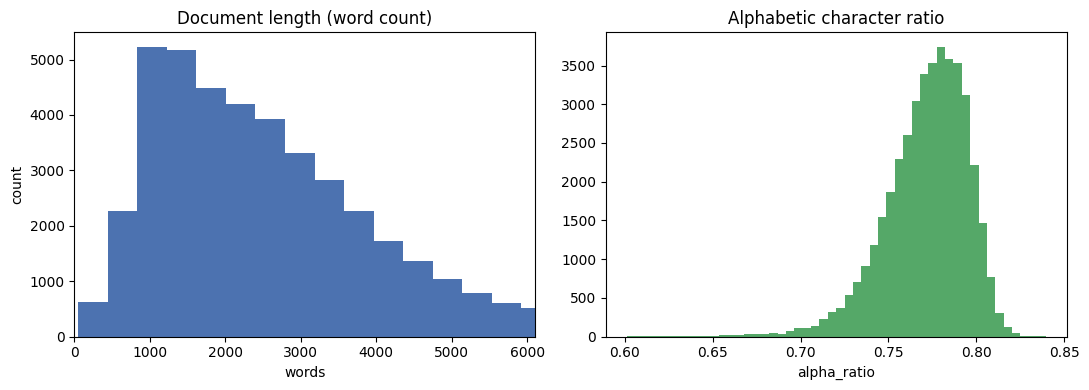

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train_df["word_count"], bins=50, color="#4C72B0")
axes[0].set_title("Document length (word count)")
axes[0].set_xlabel("words")
axes[0].set_ylabel("count")
axes[0].set_xlim(0, train_df["word_count"].quantile(0.95))

axes[1].hist(train_df["alpha_ratio"], bins=50, color="#55A868")
axes[1].set_title("Alphabetic character ratio")
axes[1].set_xlabel("alpha_ratio")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()


In [19]:
# 1. Check missing values
print("Missing values:")
print(train_df.isnull().sum())

# 2. Check duplicate medical texts
duplicate_count = train_df.duplicated(subset=["text"]).sum()
print("\nDuplicate texts:", duplicate_count)

# 3. Check unusually short and long documents
short_docs = (train_df["word_count"] < 50).sum()
long_limit = train_df["word_count"].quantile(0.95)
long_docs = (train_df["word_count"] > long_limit).sum()

print("Documents under 50 words:", short_docs)
print("95th-percentile length:", round(long_limit))
print("Documents above this length:", long_docs)

# 4. Display a few examples
for i, text in enumerate(train_df["text"].head(3), start=1):
    print(f"\n--- Example {i} ---")
    print(text[:500])

Missing values:
id             0
text           0
source         0
char_count     0
word_count     0
alpha_ratio    0
dtype: int64

Duplicate texts: 0
Documents under 50 words: 0
95th-percentile length: 6104
Documents above this length: 2110

--- Example 1 ---
all of the archival hematoxylin and eosin ( h&e ) stained slides for each patient were reviewed . 
 the nuclear grades and histologic grades were evaluated according to the nottingham grading system.9 the tumor stages were evaluated according to the 7th edition of the american joint committee on cancer ( ajcc ) criteria . 
 this study was approved by the institutional review board of the catholic university of korea ( vc10sisi0093 ) . 
 the representative tumor site was chosen on h&e slides , an

--- Example 2 ---
gallen international breast cancer conference ( 2011 ) expert panel adopted a new approach towards classifying patients for therapeutic purposes based on the recognition of intrinsic biological subtypes within the breas

Missing values:
 id             0
text           0
source         0
char_count     0
word_count     0
alpha_ratio    0
dtype: int64

Empty texts: 0
Duplicate training texts: 0

Vocabulary size: 395445
Most common words: [('were', 701875), ('from', 424871), ('are', 419051), ('this', 417477), ('patients', 392446), ('not', 310491), ('study', 286622), ('have', 267556), ('which', 265668), ('these', 211626), ('between', 207209), ('been', 206619), ('after', 196935), ('cells', 195449), ('has', 193718), ('also', 190437), ('can', 177766), ('using', 177675), ('may', 174985), ('all', 171145)]

1st percentile: 301.86
99th percentile: 8910.559999999998
Extremely short documents: 422
Extremely long documents: 422

Correlations:
             char_count  word_count  alpha_ratio
char_count     1.000000    0.996396    -0.200810
word_count     0.996396    1.000000    -0.251323
alpha_ratio   -0.200810   -0.251323     1.000000


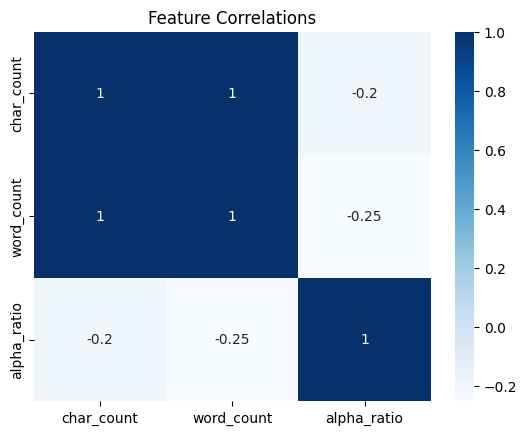

Texts containing URLs: 723
Texts with low alphabetic ratio: 0


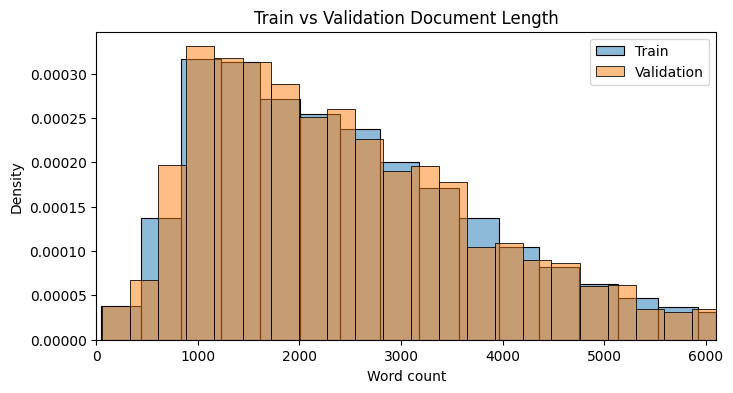


Token-length statistics:
count     2000.000000
mean      3416.907000
std       2262.793473
min         65.000000
25%       1773.750000
50%       2906.000000
75%       4375.000000
max      21607.000000
dtype: float64


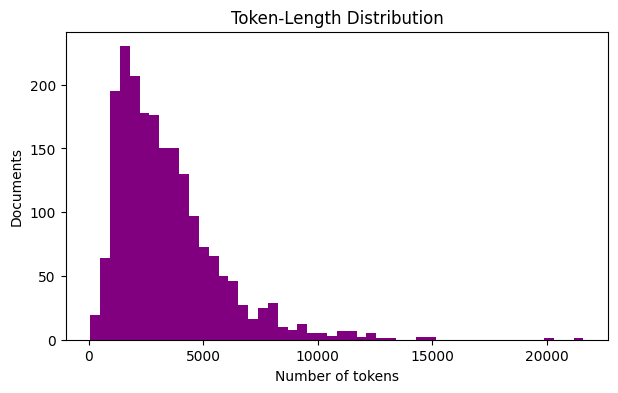

In [20]:
from collections import Counter
import re
import seaborn as sns
import matplotlib.pyplot as plt

TEXT_COL = "text"

# 1. Missing values and empty texts
print("Missing values:\n", train_df.isnull().sum())
print("\nEmpty texts:", train_df[TEXT_COL].fillna("").str.strip().eq("").sum())

# 2. Duplicate texts
print("Duplicate training texts:", train_df.duplicated(subset=[TEXT_COL]).sum())

# 3. Vocabulary size and common words
stopwords = {"the", "a", "an", "and", "of", "to", "in", "is", "was", "for", "with", "on", "that", "by", "as"}
# Count words one document at a time (joining all 42k docs into one string crashed Colab's RAM)
word_counts = Counter()
for doc in train_df[TEXT_COL].fillna(""): word_counts.update(w for w in re.findall(r"\b[a-zA-Z]{3,}\b", doc.lower()) if w not in stopwords)
print("\nVocabulary size:", len(word_counts))
print("Most common words:", word_counts.most_common(20))

# 4. Extremely short and long documents
lower_limit = train_df["word_count"].quantile(0.01)
upper_limit = train_df["word_count"].quantile(0.99)

print("\n1st percentile:", lower_limit)
print("99th percentile:", upper_limit)
print("Extremely short documents:",
      (train_df["word_count"] < lower_limit).sum())
print("Extremely long documents:",
      (train_df["word_count"] > upper_limit).sum())

# 5. Correlation between text measurements
print("\nCorrelations:")
print(train_df[["char_count", "word_count", "alpha_ratio"]].corr())

sns.heatmap(
    train_df[["char_count", "word_count", "alpha_ratio"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Feature Correlations")
plt.show()

# 6. Basic text-quality checks
print("Texts containing URLs:",
      train_df[TEXT_COL].str.contains(r"http|www\.", case=False, na=False).sum())
print("Texts with low alphabetic ratio:",
      (train_df["alpha_ratio"] < 0.5).sum())

# 7. Compare training and validation lengths
plt.figure(figsize=(8, 4))

sns.histplot(
    train_df["word_count"],
    label="Train",
    bins=50,
    stat="density",
    alpha=0.5
)

sns.histplot(
    val_df["word_count"],
    label="Validation",
    bins=50,
    stat="density",
    alpha=0.5
)

plt.xlim(0, train_df["word_count"].quantile(0.95))
plt.xlabel("Word count")
plt.title("Train vs Validation Document Length")
plt.legend()
plt.show()

# 8. Exact Llama token-length distribution
from transformers import AutoTokenizer

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

sample_texts = train_df[TEXT_COL].dropna().sample(
    min(2000, len(train_df)),
    random_state=42
)

token_lengths = [
    len(tokenizer(text, truncation=False)["input_ids"])
    for text in sample_texts
]

print("\nToken-length statistics:")
print(pd.Series(token_lengths).describe())

plt.figure(figsize=(7, 4))
plt.hist(token_lengths, bins=50, color="purple")
plt.xlabel("Number of tokens")
plt.ylabel("Documents")
plt.title("Token-Length Distribution")
plt.show()

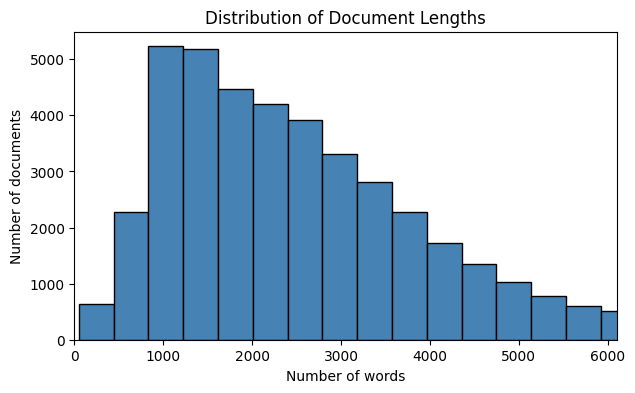

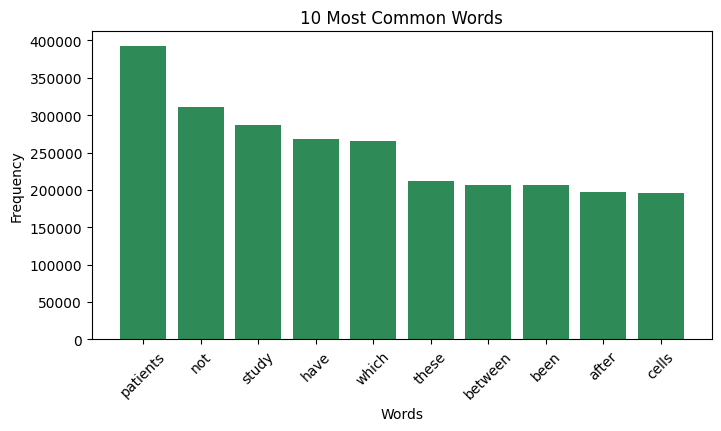

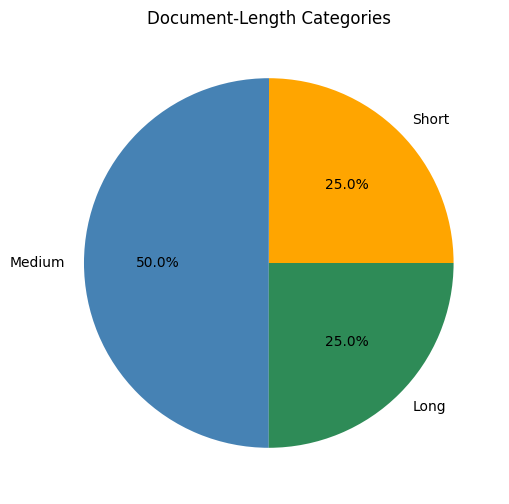

In [21]:
from collections import Counter
import matplotlib.pyplot as plt
import re

# 1. Histogram: document lengths
plt.figure(figsize=(7, 4))
plt.hist(train_df["word_count"], bins=50, color="steelblue", edgecolor="black")
plt.xlim(0, train_df["word_count"].quantile(0.95))
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.title("Distribution of Document Lengths")
plt.show()

# 2. Bar chart: most common words (counted per document to stay within Colab RAM)
stopwords = {"the", "and", "for", "that", "with", "from", "this", "was", "were", "are", "of", "to", "in", "a"}
bar_counts = Counter()
for doc in train_df["text"].fillna(""): bar_counts.update(w for w in re.findall(r"\b[a-zA-Z]{3,}\b", doc.lower()) if w not in stopwords)
common_words = bar_counts.most_common(10)
labels, counts = zip(*common_words)

plt.figure(figsize=(8, 4))
plt.bar(labels, counts, color="seagreen")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("10 Most Common Words")
plt.xticks(rotation=45)
plt.show()

# 3. Pie chart: document-length categories
q1 = train_df["word_count"].quantile(0.25)
q3 = train_df["word_count"].quantile(0.75)

short = (train_df["word_count"] < q1).sum()
medium = train_df["word_count"].between(q1, q3).sum()
long = (train_df["word_count"] > q3).sum()

plt.figure(figsize=(6, 6))
plt.pie([short, medium, long], labels=["Short", "Medium", "Long"], autopct="%1.1f%%", colors=["orange", "steelblue", "seagreen"])
plt.title("Document-Length Categories")
plt.show()

# 2. Data Processing

In [22]:
# HF token is read from Colab Secrets (key icon in left sidebar), never stored in the notebook
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [23]:
from transformers import AutoTokenizer

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
MAX_LENGTH = 512  # kept short deliberately -- see report Discussion re: Colab memory limits

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


In [24]:
N_TRAIN = 1500
N_EVAL = 200

train_subset = raw["train"].shuffle(seed=SEED).select(range(N_TRAIN))
eval_subset = raw["validation"].select(range(N_EVAL))

print("Train subset:", len(train_subset), "docs")
print("Eval subset:", len(eval_subset), "docs")

Train subset: 1500 docs
Eval subset: 200 docs


In [25]:
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )

train_tok = train_subset.map(tokenize_fn, batched=True, remove_columns=train_subset.column_names)
eval_tok = eval_subset.map(tokenize_fn, batched=True, remove_columns=eval_subset.column_names)

# Causal LM: labels = input_ids (next-token prediction at every position)
train_tok = train_tok.map(lambda ex: {"labels": ex["input_ids"]}, batched=True)
eval_tok = eval_tok.map(lambda ex: {"labels": ex["input_ids"]}, batched=True)

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
eval_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(train_tok)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1500
})


# 3. Model Loading, Baseline Evaluation, and Freezing Setup

In [26]:
from transformers import AutoConfig, AutoModelForCausalLM, BitsAndBytesConfig
import bitsandbytes as bnb

N_UNFROZEN = 2  # small on purpose -- keeps trainable params + optimizer memory low

# T4 (compute capability 7.5) has no native bf16 -> fall back to fp16 there
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
print("Compute dtype:", COMPUTE_DTYPE)

# Layers we intend to train must stay un-quantized (4-bit weights cannot hold gradients)
n_layers = AutoConfig.from_pretrained(MODEL_ID).num_hidden_layers
unfrozen_names = [f"model.layers.{i}" for i in range(n_layers - N_UNFROZEN, n_layers)]

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
    llm_int8_skip_modules=["lm_head"] + unfrozen_names,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=COMPUTE_DTYPE,
    device_map="auto",
)
model.config.use_cache = False  # required when training with gradient checkpointing
print(model.config.num_hidden_layers, "decoder layers; un-quantized:", unfrozen_names)

# Sanity check: trainable layers really are plain Linear, frozen ones really are 4-bit
assert not isinstance(model.model.layers[-1].self_attn.q_proj, bnb.nn.Linear4bit)
assert isinstance(model.model.layers[0].self_attn.q_proj, bnb.nn.Linear4bit)

Compute dtype: torch.float16


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

32 decoder layers; un-quantized: ['model.layers.30', 'model.layers.31']


### Baseline score for downloaded lama

In [27]:
import math
from torch.utils.data import DataLoader

@torch.no_grad()
def compute_perplexity(model, dataset, batch_size=2):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        batch = {k: v.to(model.device) for k, v in batch.items()}
        # Ignore padding in the loss (same as the training collator does)
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels
        with torch.autocast("cuda", dtype=COMPUTE_DTYPE):
            out = model(**batch)
        n_tokens = (labels[:, 1:] != -100).sum().item()
        total_loss += out.loss.item() * n_tokens
        total_tokens += n_tokens
    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss), avg_loss

baseline_ppl, baseline_loss = compute_perplexity(model, eval_tok)
print(f"BASELINE (no training) — held-out perplexity: {baseline_ppl:.2f} loss={baseline_loss:.4f}")

BASELINE (no training) — held-out perplexity: 8.66 loss=2.1591


### Testing the baseline

In [28]:
PROMPT = "The patient presented with symptoms of"

@torch.no_grad()
def generate_sample(model, prompt=PROMPT, max_new_tokens=80):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    # same autocast reasoning as compute_perplexity above
    with torch.autocast("cuda", dtype=COMPUTE_DTYPE):
        gen = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, use_cache=True, pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(gen[0], skip_special_tokens=True)

BASELINE_TEXT = generate_sample(model)
print("BASELINE generation (before any training):\n")
print(BASELINE_TEXT)

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


BASELINE generation (before any training):

The patient presented with symptoms of a severe allergic reaction, including difficulty breathing, rapid heartbeat, and swelling of the face and lips. The patient was treated with epinephrine, antihistamines, and corticosteroids, and was admitted to the hospital for observation. The patient's symptoms were likely caused by an allergic reaction to a medication or food, and the treatment was aimed at reversing the symptoms and preventing further complications


### Freeing the last layers

In [29]:
# Freeze everything, then unfreeze only the last N decoder layers.
# The LM head is kept un-quantized (numerical stability for the logits) but stays FROZEN:
# it's ~525M params, and training it too would roughly double the optimizer memory (see
# Discussion re: T4 VRAM budget) for a layer that mostly needs to track the trained layers below it.
for p in model.parameters():
    p.requires_grad = False

decoder_layers = model.model.layers  # Llama decoder stack
for layer in decoder_layers[-N_UNFROZEN:]:
    for p in layer.parameters():
        p.requires_grad = True

# fp16 training needs fp32 trainable weights (GradScaler cannot unscale fp16 grads)
if not USE_BF16:
    for p in model.parameters():
        if p.requires_grad:
            p.data = p.data.float()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable params: 436,224,000 / 4,758,704,128 (9.17%)


### Training

In [30]:
from transformers import DataCollatorForLanguageModeling, get_linear_schedule_with_warmup

BATCH_SIZE, GRAD_ACCUM, EPOCHS, LR, LOG_EVERY = 1, 8, 1, 5e-6, 10  # LR lowered from 2e-5 (loss rose during the 2e-5 run)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)  # masks pads in labels
g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_tok, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=data_collator, generator=g)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = bnb.optim.PagedAdamW8bit(params, lr=LR)  # 8-bit Adam states: saves several GB on a T4
total_steps = math.ceil(len(train_loader) * EPOCHS / GRAD_ACCUM)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)  # 10% warmup
scaler = torch.amp.GradScaler("cuda", enabled=not USE_BF16)

# non-reentrant checkpointing: needed because the frozen layers below the trainable ones
# produce activations that do not require grad
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.train()

train_steps, train_losses = [], []
step, running = 0, 0.0
for epoch in range(EPOCHS):
    for i, batch in enumerate(train_loader):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        with torch.autocast("cuda", dtype=COMPUTE_DTYPE):
            loss = model(**batch).loss / GRAD_ACCUM
        scaler.scale(loss).backward()
        running += loss.item()

        if (i + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            step += 1
            if step % LOG_EVERY == 0:
                train_steps.append(step)
                train_losses.append(running / LOG_EVERY)
                print(f"step {step}/{total_steps} | loss {running / LOG_EVERY:.4f}")
                running = 0.0

step 10/188 | loss 2.1770
step 20/188 | loss 2.1440
step 30/188 | loss 2.1231
step 40/188 | loss 2.1186
step 50/188 | loss 2.1131
step 60/188 | loss 2.1344
step 70/188 | loss 2.1450
step 80/188 | loss 2.0917
step 90/188 | loss 2.1047
step 100/188 | loss 2.1021
step 110/188 | loss 2.0436
step 120/188 | loss 2.0997
step 130/188 | loss 2.0194
step 140/188 | loss 2.1115
step 150/188 | loss 2.1559
step 160/188 | loss 2.1135
step 170/188 | loss 2.0604
step 180/188 | loss 2.1286


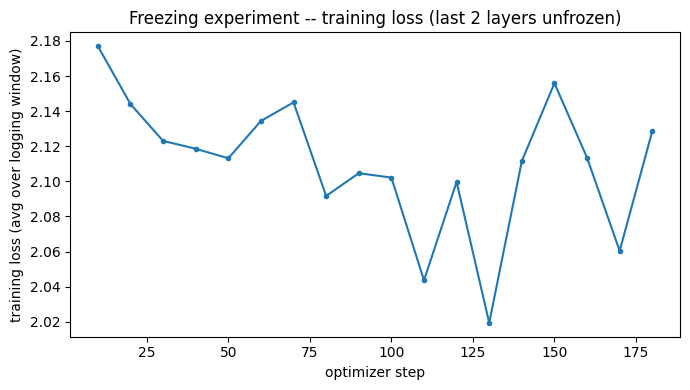

In [31]:
# Loss curve -- keep this plot for the Results section of the report
plt.figure(figsize=(7, 4))
plt.plot(train_steps, train_losses, marker="o", markersize=3)
plt.xlabel("optimizer step")
plt.ylabel("training loss (avg over logging window)")
plt.title(f"Freezing experiment -- training loss (last {N_UNFROZEN} layers unfrozen)")
plt.tight_layout()
plt.savefig("freezing_training_loss.png", dpi=150)
plt.show()

# 4. Evaluation

In [32]:
post_ppl, post_loss = compute_perplexity(model, eval_tok)
print(f"AFTER FREEZING+TRAINING — held-out perplexity: {post_ppl:.2f} (loss={post_loss:.4f})")

comparison = pd.DataFrame({
    "stage": ["Baseline (frozen, no training)", f"After freezing (last {N_UNFROZEN} layers trained)"],
    "eval_loss": [baseline_loss, post_loss],
    "perplexity": [baseline_ppl, post_ppl],
})
comparison["perplexity_change_%"] = 100 * (comparison["perplexity"] - baseline_ppl) / baseline_ppl
comparison.to_csv("results_comparison.csv", index=False)
comparison


AFTER FREEZING+TRAINING — held-out perplexity: 7.78 (loss=2.0518)


,stage,eval_loss,perplexity,perplexity_change_%
0,"Baseline (frozen, no training)",2.159097,8.663314,0.000000
1,After freezing (last 2 layers trained),2.051770,7.781663,-10.176832


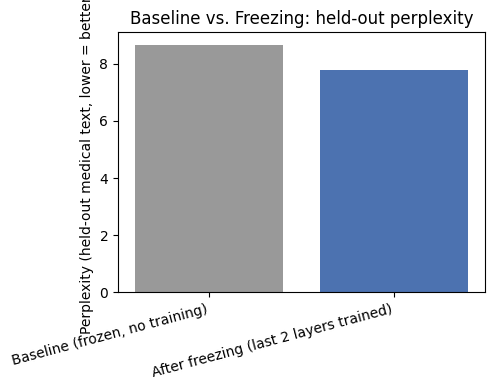

In [33]:
plt.figure(figsize=(5, 4))
plt.bar(comparison["stage"], comparison["perplexity"], color=["#999999", "#4C72B0"])
plt.ylabel("Perplexity (held-out medical text, lower = better)")
plt.title("Baseline vs. Freezing: held-out perplexity")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("perplexity_comparison.png", dpi=150)
plt.show()


In [34]:
# Qualitative before/after: same prompt, same greedy decoding, so the only difference is the training
AFTER_TEXT = generate_sample(model)
print("BEFORE training:\n", BASELINE_TEXT)
print("\nAFTER training:\n", AFTER_TEXT)

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


BEFORE training:
 The patient presented with symptoms of a severe allergic reaction, including difficulty breathing, rapid heartbeat, and swelling of the face and lips. The patient was treated with epinephrine, antihistamines, and corticosteroids, and was admitted to the hospital for observation. The patient's symptoms were likely caused by an allergic reaction to a medication or food, and the treatment was aimed at reversing the symptoms and preventing further complications

AFTER training:
 The patient presented with symptoms of a severe headache and vomiting. 
 the patient was admitted to the hospital and underwent a series of tests, including a ct scan and an mri. 
 the test results showed that the patient had a brain tumor. 
 the patient was referred to a neurosurgeon for further evaluation and treatment. 
 the neurosurgeon performed a craniotomy to remove the tumor. 
 the patient was
